# *B. megaterium* (iJA1121) + *P. aeruginosa* (iSD1509) — co-culture on strawberry root exudate

Both organisms in one 1×1 well, sharing a single pool of SUGAR-SHIFTED strawberry root
exudate: fourteen carbon compounds totalling **142 µmol C/L**, 80% of it in sugars
*P. aeruginosa* cannot metabolise. Equal inoculum, 1e-8 g each.

`SALTS_MM`, `BULK`, `VMAX` and `DEFAULT_KM` are still copied verbatim from
`B_megaterium_iJA1121_minimal_medium.ipynb` and `P_aeruginosa_iSD1509_minimal_medium.ipynb`;
only `EXUDATE_UM` has moved. Total carbon is pinned at the FRESH profile's 142 µmol C/L, so
the two are directly comparable — the same amount of food, put somewhere else. On FRESH,
citrate alone was 55% of the carbon and *P. aeruginosa* ended with 76% of the biomass.

**What to expect.** *P. aeruginosa* gets ~1.7× more biomass out of a mmol of carbon than
*B. megaterium* (0.0127 vs 0.0076 gDW/mmol C), so an even split of the pool still loses:
*B. megaterium* needs about 63% of the carbon just to draw. Here it is handed 80% of it in
compounds iSD1509 has no route for, so the expected outcome is a clear *B. megaterium*
win — roughly the mirror image of FRESH — with *P. aeruginosa* squeezed onto the 12.5%
left in citrate, glutamate, aspartate and serine. Unlike the 65% variant this one is not
near the tipping point (that sits around 62%), so the outcome should survive a fair amount
of nudging of the uptake kinetics. Note *B. megaterium*'s own biomass peaks around here:
push the sugar share higher and it starts losing the citrate and amino acids it was also
scavenging. Neither organism secretes anything organic, so the interaction is still pure
competition; `cross-fed candidates` in the results is the line that would falsify that.

Nitrate is left out of the salt mix even though the recipe is 4.5 mM NH4NO3. This notebook
opens every exchange bound and hands uptake to COMETS, which turns a static, unlimited
nitrate pool into a free electron sink — the model reduces it to ammonium, excretes that,
and grows several-fold faster than published. Both reconstructions ship with `EX_no3_e`
closed; leaving nitrate out respects that.

Oxygen is held static because iSD1509 does not grow anaerobically, with or without nitrate,
so letting O2 run out would stop the culture rather than shift it to fermentation.

In [11]:
import os

import cobra
import cometspy as c
import matplotlib.pyplot as plt
import numpy as np

## Helpers

In [12]:
def find_file(name, folders=('.', '..', '/workspace/notebooks')):
    """Absolute path to `name`, searched across `folders`."""
    for folder in folders:
        path = os.path.join(folder, name)
        if os.path.isfile(path):
            return os.path.abspath(path)
    raise FileNotFoundError(
        f"{name!r} not found in {list(folders)} (cwd {os.getcwd()!r}). "
        "If running in the COMETS container, this folder is probably not bind-mounted."
    )


def exchange_map(model):
    """{metabolite id: exchange reaction id}."""
    return {list(rxn.metabolites)[0].id: rxn.id for rxn in model.exchanges}


def make_medium(exudate_uM, salts_mM, bulk, unavailable):
    """(medium in mmol per 1 cm3 box, ids to hold static); only the exudate is consumable."""
    medium = {met: value * 1e-6 for met, value in exudate_uM.items()      # uM -> mmol/cm3
              if met not in unavailable}
    medium.update({met: value * 1e-3 for met, value in salts_mM.items()   # mM -> mmol/cm3
                   if met not in unavailable})
    medium.update(bulk)
    return medium, set(medium) - set(exudate_uM)


def scale_to_carbon_cap(kinetics, cap, exudate_uM, carbon_of):
    """Rescale every Vmax by one shared factor so that total carbon uptake at the initial
    exudate equals `cap` mmol C/gDW/h.

    The published caps used to be printed and then ignored, which let a hand-tuned Vmax
    table quietly hand a strain three times its measured uptake capacity. Scaling by a
    single factor pins the total to the published number while leaving the *relative*
    preferences - the thing that decides who eats what - exactly as written below.
    """
    draw = {met: vmax * (exudate_uM[met] * 1e-6) / (exudate_uM[met] * 1e-6 + km)
                 * carbon_of(met)
            for met, (vmax, km) in kinetics.items()}
    factor = cap / sum(draw.values())
    return {met: (vmax * factor, km) for met, (vmax, km) in kinetics.items()}


def carbon_draw(kinetics, exudate_uM, carbon_of):
    """{metabolite: mmol C/gDW/h} pulled at the initial exudate - the niche, made visible."""
    return {met: round(vmax * (exudate_uM[met] * 1e-6) / (exudate_uM[met] * 1e-6 + km)
                       * carbon_of(met), 2)
            for met, (vmax, km) in kinetics.items() if met in exudate_uM}


def set_kinetics(comets_model, rxn_id, vmax, km):
    """Per-reaction Vmax and Km on a cometspy model.

    `change_vmax` exists on every cometspy release; `change_km` only on newer ones. Both
    write the same V_MAX / KM columns, so fall back to the dataframe when it is missing.
    """
    comets_model.change_vmax(rxn_id, vmax)
    if hasattr(comets_model, 'change_km'):
        comets_model.change_km(rxn_id, km)
    else:
        comets_model.reactions.loc[
            comets_model.reactions.REACTION_NAMES == rxn_id, 'KM'] = km


def make_layout(medium, static_mets, models):
    """1x1 well; metabolites in `static_mets` are pinned at their initial level.

    Models go in *before* the metabolites. cometspy checks each metabolite against the
    models already present, so the other order makes all 25 components fire a
    "not able to be taken up" warning and a genuine typo hides in the noise.
    """
    layout = c.layout()
    layout.grid = [1, 1]
    for comets_model in models:
        layout.add_model(comets_model)
    for met, amount in medium.items():
        layout.set_specific_metabolite(met, amount, static=(met in static_mets))
    return layout


def make_comets_model(model, model_id, exchanges, kinetics, biomass, blocked=()):
    """cometspy model with COMETS in charge of uptake.

    `kinetics` is {metabolite: (Vmax, Km)}; anything unlisted falls back to the
    simulation-wide DEFAULT_VMAX / DEFAULT_KM. Metabolites in `blocked` keep their
    secretion route but can never be taken up - use it where the reconstruction has an
    exchange but no working catabolic route, so the niche is a stated choice rather than
    an accident of the network.
    """
    cm = c.model(model)
    cm.id = model_id
    for rxn in model.boundary:                       # keep cytosolic sinks internal
        mets = list(rxn.metabolites)
        if len(mets) == 1 and mets[0].compartment != 'e':
            cm.reactions.loc[cm.reactions.REACTION_NAMES == rxn.id, 'EXCH'] = False
            cm.reactions.loc[cm.reactions.REACTION_NAMES == rxn.id, 'EXCH_IND'] = 0
    for rxn in model.exchanges:                      # COMETS resets uptake every cycle
        cm.change_bounds(rxn.id, -1000, 1000)
    for met in blocked:                              # secretion only, never uptake
        if met in exchanges:
            cm.change_bounds(exchanges[met], 0, 1000)
    for met, (vmax, km) in kinetics.items():
        set_kinetics(cm, exchanges[met], vmax, km)
    cm.initial_pop = [0, 0, biomass]
    cm.optimizer = 'GLOP'
    
    cm.obj_style = 'MAXIMIZE_OBJECTIVE_FLUX'
    return cm


def fba_on_medium(model, comets_model, medium, exchanges, default_vmax, default_km,
                  blocked=()):
    """FBA under the uptake bounds COMETS will impose on its first cycle.

    Each bound is Monod-throttled at the initial concentration using *that reaction's own*
    Vmax and Km, so a substrate the strain has been given a repressed (high) Km for comes
    in slowly here too - which is the whole point of the split. In a co-culture the medium
    also carries the partner's metabolites, which this model has no exchange for.
    """
    caps = comets_model.reactions.set_index('REACTION_NAMES')
    with model as m:
        for rxn in m.exchanges:                      # nothing is available by default
            rxn.lower_bound = 0.0
        for met, amount in medium.items():
            if met not in exchanges or met in blocked:
                continue                             # partner's metabolite, or no route
            rxn = m.reactions.get_by_id(exchanges[met])
            row = caps.loc[rxn.id] if rxn.id in caps.index else None
            vmax = getattr(row, 'V_MAX', np.nan) if row is not None else np.nan
            km = getattr(row, 'KM', np.nan) if row is not None else np.nan
            vmax = vmax if vmax == vmax else default_vmax      # NaN means "use default"
            km = km if km == km else default_km
            rxn.lower_bound = -vmax * amount / (amount + km)
        return m.optimize()


def exchange_fluxes(solution, exchanges, tol=1e-4):
    """(uptake, secretion) as {metabolite: rate}."""
    names = {rxn: met for met, rxn in exchanges.items()}
    flux = {names[rxn]: solution.fluxes[rxn] for rxn in exchanges.values()}
    return ({m: round(-v, 3) for m, v in flux.items() if v < -tol},
            {m: round(v, 3) for m, v in flux.items() if v > tol})

## Configuration

In [13]:
# Strawberry root exudate, SUGAR-SHIFTED profile, in uM. Same 142 umol C/L as FRESH -
# the carbon has only been moved, not added. 80% of it now sits in eight sugars iSD1509
# has no catabolic route for, 7.5% in the two hexoses both strains take, and the
# remaining 12.5% in the citrate/amino-acid fraction P. aeruginosa prefers.
EXUDATE_UM = {'cit_e': 8.284, 'glu__L_e': 1.072, 'asp__L_e': 0.515, 'ser__L_e': 0.260,
              'glc__D_e': 1.065, 'fru_e': 0.710, 'sucr_e': 3.313, 'raffin_e': 1.262,
              'malt_e': 1.420, 'tre_e': 0.947, 'cellb_e': 0.757, 'gal_e': 0.947,
              'xyl__D_e': 0.909, 'sbt__D_e': 0.568}

# Hydroponic nutrient solution, in mM. Held static, so carbon is the only thing that can
# run out. Nitrate is deliberately absent: see the header.
NH4_INITIAL_MM = 0.0  # initial extracellular ammonium; SALTS_MM values are mM
SALTS_MM = {'nh4_e': NH4_INITIAL_MM, 'k_e': 6.3, 'cl_e': 16.03, 'ca2_e': 5.0,
            'mg2_e': 2.0, 'so4_e': 2.087, 'pi_e': 0.3, 'mn2_e': 0.01438,
            'zn2_e': 0.00076, 'mobd_e': 0.00033, 'na1_e': 0.00066, 'fe2_e': 0.08669,
            'o2_e': 0.2, 'cu2_e': 0.001, 'cobalt2_e': 0.0001}

BULK = {'h2o_e': 1000.0, 'h_e': 1000.0}   # co2_e omitted so it can only ever be a product

# Nothing is dropped here: the medium is one shared pool and every component is usable by
# at least one partner. The eight sugars are B. megaterium's alone (see BLOCKED_PA);
# Cl/Mn/Mo/Cu are P. aeruginosa's alone (no exchange in iJA1121).
UNAVAILABLE = set()

DEFAULT_VMAX = 25.0
DEFAULT_KM = 3e-6         # 3 uM, at the top of the exudate's 0.26-3.3 uM range
TIME_STEP = 0.05
SIM_HOURS = 24
INITIAL_BIOMASS = 1e-8    # equal inoculum; 142 umol C/L supports only ~2e-6 g in total

# --- Uptake kinetics: the only thing that decides who eats what ----------------------
#
# COMETS throttles every uptake by Vmax * S / (Km + S). Give two strains the same Km on
# every compound and their *relative* preferences are identical - they are one competitor
# occupying one niche, and by competitive exclusion the faster one takes the entire pool.
# That is what the earlier flat `VMAX_BM = 1.8 for every met` / `VMAX_PA = 4.2 for every
# met` did: B. megaterium lost all six contested compounds and survived only on the two
# P. aeruginosa physically cannot touch (sucrose, sorbitol = 7.5% of the carbon).
#
# Coexistence needs a trade-off, i.e. each strain must be the better competitor for at
# least one substrate. These two have one, and it is documented: their catabolite
# repression hierarchies run in opposite directions.
#   P. aeruginosa - Crc/CrcZ represses sugar catabolism while organic acids and amino
#                   acids are available. Citrate, glutamate, aspartate and serine are the
#                   preferred sources; glucose and fructose are the repressed ones.
#   B. megaterium - CcpA-type hierarchy, the familiar one: PTS sugars first (glucose,
#                   fructose, sucrose), polyols next, carboxylic acids last.
#
# Preferred = high affinity (Km at or under the 0.26-3.3 uM supplied) plus high Vmax.
# Repressed = Km far above the supplied concentration, so uptake sits at a few percent of
# Vmax and only matters once the preferred pool is gone. Note nothing is switched off:
# both strains can still scavenge the other's substrates, they are just bad at it.
KM_PREFERRED = 0.5e-6     # 0.5 uM: at or below all but the two smallest amino acids
KM_REPRESSED = 20e-6      # 20 uM: above every supplied concentration, so ~1-15% of Vmax
NH4_VMAX_BM = 25.0        # mmol NH4/gDW/h; explicit B. megaterium uptake capacity
NH4_KM_BM = 8e-6          # mmol/cm3 = 8 uM; proxy from B. acidocaldarius, paper p.14

KINETICS_BM_RAW = {                                  # the sugars and the polyol are its own
    'glc__D_e': (6.0, KM_PREFERRED),                 # hexose PTS, the top of the hierarchy
    'fru_e':    (5.0, KM_PREFERRED), 'sucr_e':   (5.0, KM_PREFERRED),
    'malt_e':   (5.0, KM_PREFERRED), 'tre_e':    (5.0, KM_PREFERRED),
    'cellb_e':  (5.0, KM_PREFERRED),                 # di-/trisaccharides and the pentose
    'raffin_e': (4.0, KM_PREFERRED), 'gal_e':    (4.0, KM_PREFERRED),
    'xyl__D_e': (4.0, KM_PREFERRED), 'sbt__D_e': (4.0, KM_PREFERRED),
    'cit_e':    (1.2, KM_REPRESSED), 'glu__L_e':  (1.2, KM_REPRESSED),
    'asp__L_e': (1.2, KM_REPRESSED), 'ser__L_e':  (1.2, KM_REPRESSED),
}

KINETICS_PA_RAW = {                                  # citrate and amino acids are its own
    'cit_e':    (7.0, KM_PREFERRED), 'glu__L_e': (5.0, KM_PREFERRED),
    'asp__L_e': (4.0, KM_PREFERRED), 'ser__L_e': (4.0, KM_PREFERRED),
    'glc__D_e': (0.8, KM_REPRESSED), 'fru_e':   (0.8, KM_REPRESSED),
}                                                    # the eight sugars: no route at all

# Eight of the fourteen carbon compounds are B. megaterium's alone, in two different
# ways. Sucrose and raffinose are missing from iSD1509 outright - no EX_ reaction, so
# COMETS never offers them. The other six do have an exchange and a transporter but no
# consumer for the cytosolic form: EX_sbt__D_e plus rJB00222 (sbt__D_e -> sbt__D_c) with
# nothing downstream of sbt__D_c is the pattern, and maltose, trehalose, cellobiose,
# galactose and xylose repeat it. Single-substrate FBA puts all six at mu = 0. Blocking
# them says so out loud instead of relying on the FBA to notice.
BLOCKED_PA = {'sbt__D_e', 'malt_e', 'tre_e', 'cellb_e', 'gal_e', 'xyl__D_e'}

MODEL_FILE_BM = 'B_megaterium_DSM319_iJA1121_bigg.xml'
MODEL_ID_BM   = 'B_megaterium'
CARBON_CAP_BM = 30.0                                 # 5 mmol glucose/gDW/h, as published

MODEL_FILE_PA = 'P_aeruginosa_iSD1509.xml'
MODEL_ID_PA   = 'P_aeruginosa'
CARBON_CAP_PA = 60.0                                 # 10 mmol glucose/gDW/h, as published
VMAX_O2_PA    = 20.0                                 # the model's own published constraint

## Model and layout

In [14]:
model_bm = cobra.io.read_sbml_model(find_file(MODEL_FILE_BM))
exchanges_bm = exchange_map(model_bm)

model_pa = cobra.io.read_sbml_model(find_file(MODEL_FILE_PA))
model_pa.reactions.get_by_id('ATPM').bounds = (0.0, 8.39)   # 只有 iSD1509 有这个反应
exchanges_pa = exchange_map(model_pa)

medium, static_mets = make_medium(EXUDATE_UM, SALTS_MM, BULK, UNAVAILABLE)
static_mets.discard('nh4_e')  # NH4 must remain in the shared pool for cross-feeding


def carbon(met):
    for mdl in (model_bm, model_pa):
        if mdl.metabolites.has_id(met):
            return (mdl.metabolites.get_by_id(met).elements or {}).get('C')


def usable(met):
    """True when at least one partner has both an exchange and a transporter for `met`."""
    return any(mdl.metabolites.has_id(met)
               and len(mdl.metabolites.get_by_id(met).reactions) > 1
               for mdl in (model_bm, model_pa))


assert not [m for m in medium
            if m not in exchanges_bm and m not in exchanges_pa], \
    "medium metabolite has no exchange in either model"
assert not [m for m in medium if not usable(m)], \
    "medium metabolite is a dead end in both models - it can never be taken up"
assert not [m for m in static_mets if carbon(m)], \
    "a static metabolite carries carbon - it would be an unlimited carbon source"

# Pin each strain's total carbon uptake to its published cap, then look at where that
# carbon comes from. These two dicts are the niche split, in mmol C/gDW/h.
KINETICS_BM = scale_to_carbon_cap(KINETICS_BM_RAW, CARBON_CAP_BM, EXUDATE_UM, carbon)
KINETICS_PA = scale_to_carbon_cap(KINETICS_PA_RAW, CARBON_CAP_PA, EXUDATE_UM, carbon)

draw_bm, draw_pa = (carbon_draw(KINETICS_BM, EXUDATE_UM, carbon),
                    carbon_draw(KINETICS_PA, EXUDATE_UM, carbon))
sugars = {'glc__D_e', 'fru_e', 'sucr_e', 'raffin_e', 'malt_e', 'tre_e', 'cellb_e',
          'gal_e', 'xyl__D_e', 'sbt__D_e'}

print(f"{'compound':10s} {'umol C':>7s} {MODEL_ID_BM:>14s} {MODEL_ID_PA:>14s}   who")
for met in sorted(EXUDATE_UM, key=lambda m: -EXUDATE_UM[m] * carbon(m)):
    bm, pa = draw_bm.get(met, 0.0), draw_pa.get(met, 0.0)
    print(f"{met:10s} {EXUDATE_UM[met] * carbon(met):7.1f} {bm:14.2f} {pa:14.2f}"
          f"   {MODEL_ID_BM if bm > pa else MODEL_ID_PA}")
print(f"{'total':10s} {sum(EXUDATE_UM[m] * carbon(m) for m in EXUDATE_UM):7.1f} "
      f"{sum(draw_bm.values()):14.2f} {sum(draw_pa.values()):14.2f}"
      f"   (caps {CARBON_CAP_BM:.0f} / {CARBON_CAP_PA:.0f})")
print(f"\nsugar+polyol share of initial uptake  {MODEL_ID_BM}: "
      f"{sum(v for m, v in draw_bm.items() if m in sugars) / sum(draw_bm.values()):.0%}  "
      f"{MODEL_ID_PA}: "
      f"{sum(v for m, v in draw_pa.items() if m in sugars) / sum(draw_pa.values()):.0%}")

KINETICS_BM['nh4_e'] = (NH4_VMAX_BM, NH4_KM_BM)
comets_bm = make_comets_model(model_bm, MODEL_ID_BM, exchanges_bm, KINETICS_BM,
                              INITIAL_BIOMASS)
comets_pa = make_comets_model(model_pa, MODEL_ID_PA, exchanges_pa,
                              {**KINETICS_PA, 'o2_e': (VMAX_O2_PA, DEFAULT_KM)},
                              INITIAL_BIOMASS, blocked=BLOCKED_PA)
layout = make_layout(medium, static_mets, [comets_bm, comets_pa])

https://doi.org/10.1101/2021.03.10.434463 does not conform to 'http(s)://identifiers.org/collection/id' or'http(s)://identifiers.org/COLLECTION:id


compound    umol C   B_megaterium   P_aeruginosa   who
cit_e         49.7           0.20          34.30   P_aeruginosa
sucr_e        39.8           5.05           0.00   B_megaterium
raffin_e      22.7           5.00           0.00   B_megaterium
malt_e        17.0           4.30           0.00   B_megaterium
tre_e         11.4           3.81           0.00   B_megaterium
cellb_e        9.1           3.50           0.00   B_megaterium
glc__D_e       6.4           2.37           0.21   B_megaterium
gal_e          5.7           1.52           0.00   B_megaterium
glu__L_e       5.4           0.03          14.76   P_aeruginosa
xyl__D_e       4.5           1.25           0.00   B_megaterium
fru_e          4.3           1.71           0.14   B_megaterium
sbt__D_e       3.4           1.24           0.00   B_megaterium
asp__L_e       2.1           0.01           7.03   P_aeruginosa
ser__L_e       0.8           0.00           3.55   P_aeruginosa
total        182.1          29.99          59.99 

/usr/local/lib/python3.10/site-packages/cometspy/layout.py:887: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0063' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.media.loc[self.media['metabolite'] == met,


## Pre-flight check

FBA on the medium COMETS will actually present, before spending time on the simulation.

In [15]:
shared = set(exchanges_bm) & set(exchanges_pa)
legacy = sorted(m for m in set(exchanges_bm) | set(exchanges_pa) if '__91__' in m)

print(f"extracellular metabolites  {MODEL_ID_BM}: {len(exchanges_bm)}  "
      f"{MODEL_ID_PA}: {len(exchanges_pa)}")
print(f"shared (exchangeable)      {len(shared)}")
print(f"media pools in layout      {len(layout.media)}")
print(f"unconverted legacy ids     {legacy or 'none'}")


extracellular metabolites  B_megaterium: 182  P_aeruginosa: 242
shared (exchangeable)      123
media pools in layout      301
unconverted legacy ids     none


In [16]:
sol_bm = fba_on_medium(model_bm, comets_bm, medium, exchanges_bm, DEFAULT_VMAX, DEFAULT_KM)
sol_pa = fba_on_medium(model_pa, comets_pa, medium, exchanges_pa, DEFAULT_VMAX, DEFAULT_KM)
assert sol_bm.status == 'optimal', "B. megaterium FBA failed"
assert sol_pa.status == 'optimal', "P. aeruginosa FBA failed"
if NH4_INITIAL_MM == 0:
    print('NH4_INITIAL_MM=0: no initial nitrogen; monoculture zero growth is expected.')
else:
    assert sol_bm.objective_value > 1e-6, 'B. megaterium does not grow on this medium'
    assert sol_pa.objective_value > 1e-6, 'P. aeruginosa does not grow on this medium'

mu_bm, mu_pa = sol_bm.objective_value, sol_pa.objective_value
uptake_bm, secretion_bm = exchange_fluxes(sol_bm, exchanges_bm)
uptake_pa, secretion_pa = exchange_fluxes(sol_pa, exchanges_pa)


def carbon_in(uptake):
    """mmol C/gDW/h drawn from the exudate."""
    return sum(rate * carbon(met) for met, rate in uptake.items() if met in EXUDATE_UM)


supplied = sum(medium[m] * carbon(m) for m in EXUDATE_UM if m in medium)

print(f"{MODEL_ID_BM}  mu {mu_bm:.4f} /h  carbon in {carbon_in(uptake_bm):.1f} "
      f"(cap {CARBON_CAP_BM:.0f})")
print(f"   uptake    {uptake_bm}")
print(f"   secretion {secretion_bm}")
print(f"{MODEL_ID_PA}  mu {mu_pa:.4f} /h  carbon in {carbon_in(uptake_pa):.1f} "
      f"(cap {CARBON_CAP_PA:.0f})")
print(f"   uptake    {uptake_pa}")
print(f"   secretion {secretion_pa}")
print(f"carbon pool  {supplied * 1e6:.1f} umol C, shared - not {supplied * 1e6:.1f} each")

max_cycles = int(SIM_HOURS / TIME_STEP)

NH4_INITIAL_MM=0: no initial nitrogen; monoculture zero growth is expected.
B_megaterium  mu 0.0013 /h  carbon in 0.9 (cap 30)
   uptake    {'so4_e': np.float64(0.0), 'fru_e': np.float64(0.096), 'tre_e': np.float64(0.001), 'o2_e': np.float64(0.004), 'k_e': np.float64(0.001), 'mg2_e': np.float64(0.0), 'pi_e': np.float64(0.001), 'gal_e': np.float64(0.046), 'cit_e': np.float64(0.006), 'asp__L_e': np.float64(0.003), 'glu__L_e': np.float64(0.006), 'ser__L_e': np.float64(0.001)}
   secretion {'co2_e': np.float64(0.02), 'h2o_e': np.float64(0.013), 'h_e': np.float64(0.065), 'ac_e': np.float64(0.002), 'pyr_e': np.float64(0.1), 'sbt__D_e': np.float64(0.096), 'prpnte_e': np.float64(0.0)}
P_aeruginosa  mu 0.6382 /h  carbon in 60.0 (cap 60)
   uptake    {'glc__D_e': np.float64(0.035), 'h_e': np.float64(4.494), 'pi_e': np.float64(0.563), 'ser__L_e': np.float64(1.185), 'asp__L_e': np.float64(1.757), 'cit_e': np.float64(5.717), 'o2_e': np.float64(13.465), 'glu__L_e': np.float64(2.953), 'fe2_e': np.flo

## Run

In [17]:
params = c.params()
for key, value in {
    'numRunThreads': 1,
    'defaultVmax': DEFAULT_VMAX,
    'defaultKm': DEFAULT_KM,
    'maxCycles': max_cycles,
    'timeStep': TIME_STEP,
    'spaceWidth': 1,
    'maxSpaceBiomass': 10,
    'minSpaceBiomass': 1e-11,
    'deathRate': 0.0,
    'writeMediaLog': True,
    'writeTotalBiomassLog': True,
    # The media log only ever holds the *net* pool: if one partner secretes 5 and the
    # other consumes 5, the trace is a flat line - the strongest possible cross-feeding,
    # completely invisible. Attributing an exchange to an organism needs the per-species
    # flux log, which is what `crossfeeding_figure.py` reads.
    'writeFluxLog': True,
    'FluxLogRate': 1,
}.items():
    params.set_param(key, value)

experiment = c.comets(layout, params)
experiment.run(False)

GUROBI_HOME not found. Skipping Gurobi import.
These are the expected locations for dependencies:
Dependency 			 expected path
__________ 			 _____________
or_tools_linux			/opt/comets_linux/lib/or-tools/9.4.1874/*

  You have two options to fix this problem:
1.  set each class path correctly by doing:
    comets.set_classpath(libraryname, path)
    e.g.   comets.set_classpath('hamcrest', '/home/chaco001/comets/junit/hamcrest-core-1.3.jar')

    note that versions dont always have to exactly match, but you're on your own if they don't

2.  fully define the classpath yourself by overwriting comets.JAVA_CLASSPATH
       look at the current comets.JAVA_CLASSPATH to see how this should look.

Running COMETS simulation ...
Done!


## Results

In [18]:
biomass = experiment.total_biomass.copy()
biomass.columns = ['cycle', MODEL_ID_BM, MODEL_ID_PA]
biomass['time_h'] = biomass.cycle * TIME_STEP

media = experiment.media.copy()
media['time_h'] = media.cycle * TIME_STEP
levels = media.groupby('metabolite').conc_mmol
change = levels.max() - levels.min()
changed = sorted(change[(change > 1e-12)
                        & (~change.index.isin(static_mets))].index)   # skip static/bulk
secreted = [m for m in changed if m not in medium]     # never supplied, so it was excreted


def observed_mu(column):
    """Exponential-phase slope; nan when the suppressed partner has too few points."""
    exponential = biomass[biomass[column] < 0.25 * biomass[column].iloc[-1]]
    if len(exponential) < 3:
        return float('nan')
    return np.polyfit(exponential.time_h, np.log(exponential[column]), 1)[0]


share = biomass[MODEL_ID_PA].iloc[-1] / (biomass[MODEL_ID_BM].iloc[-1]
                                         + biomass[MODEL_ID_PA].iloc[-1])

print(f"{MODEL_ID_BM}  mu alone {mu_bm:.4f}  co-culture {observed_mu(MODEL_ID_BM):.4f}  "
      f"final {biomass[MODEL_ID_BM].iloc[-1]:.4e} g")
print(f"{MODEL_ID_PA}  mu alone {mu_pa:.4f}  co-culture {observed_mu(MODEL_ID_PA):.4f}  "
      f"final {biomass[MODEL_ID_PA].iloc[-1]:.4e} g")
print(f"final community  {MODEL_ID_PA} takes {share:.1%} of the biomass")
print(f"changing metabolites  {changed}")
print(f"cross-fed candidates  {secreted or 'none'}")

B_megaterium  mu alone 0.0013  co-culture nan  final 1.0054e-08 g
P_aeruginosa  mu alone 0.6382  co-culture 0.6058  final 2.0991e-07 g
final community  P_aeruginosa takes 95.4% of the biomass
changing metabolites  ['34dhbz_e', 'ac_e', 'acac_e', 'asp__L_e', 'cellb_e', 'cit_e', 'co2_e', 'fru_e', 'gal_e', 'glc__D_e', 'glu__L_e', 'glyc_e', 'glyclt_e', 'malt_e', 'ppi_e', 'raffin_e', 'sbt__D_e', 'ser__L_e', 'skm_e', 'stys_e', 'xyl__D_e']
cross-fed candidates  ['34dhbz_e', 'ac_e', 'acac_e', 'co2_e', 'glyc_e', 'glyclt_e', 'ppi_e', 'skm_e', 'stys_e']


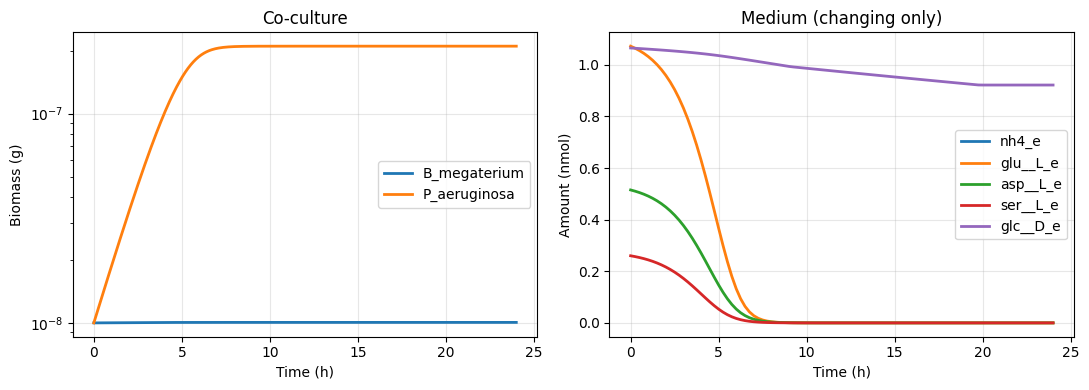

In [22]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

left.plot(biomass.time_h, biomass[MODEL_ID_BM], lw=2, label=MODEL_ID_BM)
left.plot(biomass.time_h, biomass[MODEL_ID_PA], lw=2, label=MODEL_ID_PA)
left.set(xlabel='Time (h)', ylabel='Biomass (g)', title='Co-culture', yscale='log')
left.legend()
left.grid(alpha=0.3)
changed= ['nh4_e', 'glu__L_e','asp__L_e','ser__L_e','glc__D_e']
for met in changed:
    sub = media[media.metabolite == met]
    right.plot(sub.time_h, sub.conc_mmol * 1e6, lw=2, label=met)   # 1 cm3 box: nmol == uM
right.set(xlabel='Time (h)', ylabel='Amount (nmol)', title='Medium (changing only)')
right.legend()
right.grid(alpha=0.3)

fig.tight_layout()

### Notes

- The pre-flight is a **monoculture** baseline: each model is solved against the full
  medium, which in the co-culture neither organism gets to keep. `mu alone` vs
  `co-culture` in the results is the comparison that matters.
- `cross-fed candidates` lists metabolites that changed but were never supplied, i.e. one
  partner excreted them. `co2_e` always appears and is not cross-feeding. Watch for
  `ppi_e`, which showed up on the old glucose medium — extracellular pyrophosphate is
  usually a model artefact rather than a real exchange, so check it has a transporter
  before reading anything into it.
- Both partners start at 1e-8 g. Equal inoculum is a choice, not data; the winner on a
  shared carbon pool depends on it. Re-run with a 100:1 *B. megaterium* head start to see
  whether the outcome is decided by growth rate or by starting abundance.
- `deathRate` is 0, so neither partner can be driven out — the loser plateaus at whatever
  biomass it reached, it does not wash out. Any "exclusion" here means "stopped growing",
  not "eliminated".
- Salts, O2, water and H+ are static, so carbon is the only resource in contention. CO2 is
  left out of the medium entirely so it can only ever appear as a product.
- iSD1509's ATPM is relaxed to (0, 8.39); with the published fixed value the final cycles
  would be infeasible solves rather than a clean plateau. iJA1121 has no maintenance demand
  to begin with.
- `obj_style` 必须是 `MAXIMIZE_OBJECTIVE_FLUX`。换成 `MAX_OBJECTIVE_MIN_TOTAL` 生长曲线、
  培养基耗尽曲线一模一样，但 COMETS 写出的 flux log 不再是它实际拿去更新培养基的
  那个解：cit/glc/sucr 的交换通量全是 0，却凭空吃进 shikimate/quinate/valine。
  拿那种 log 画出来的 cross-feeding 全是 infeasible loop 的伪迹。`crossfeeding_figure.py`
  现在会把 flux log 积分和 media log 净变化对账，对不上就拒绝画；`verify_fluxlog.py`
  可以单独跑这个对账。


In [20]:
## Cross-feeding figure
#
# Run this right after the simulation. cometspy rewrites `B_megaterium.cmd` /
# `P_aeruginosa.cmd` on every run, and those files are what give the flux log's columns
# their reaction names - so a later run silently invalidates this run's flux log. The
# script refuses to plot when it detects that, but the safe habit is to plot now.
import subprocess
import sys

flux_log = experiment.parameters.all_params.get('FluxLogName', '')
print(subprocess.run([sys.executable, 'crossfeeding_figure.py', flux_log,
                      '-o', 'crossfeeding_Bmeg_Paer_trans.pdf'],
                     capture_output=True, text=True).stdout or 'see stderr')


run 0x7cf96e1cfd60   24.0 h   timeStep 0.05 h   FluxLogRate 1   480 flux samples
models: B. megaterium (#1), P. aeruginosa (#2)

metabolite    class      B. megaterium upB. megaterium secP. aeruginosa upP. aeruginosa sec    [nmol]
-------------------------------------------------------------------------------------------
ac_e          cross-fed            0.3199                0           2.606            2.942
acac_e        cross-fed                 0           0.2463          0.2478                0
glyc_e        cross-fed                 0           0.1984          0.2009                0
skm_e         cross-fed                 0          0.03874         0.03923                0
cit_e         shared             0.002516                0           8.338                0
glc__D_e      shared              0.03582                0          0.1081                0
fru_e         shared              0.02566                0         0.07297                0

自检  net exchange vs media log 净

In [21]:
## Run archive + cross-feeding snapshots
#
# 跑完立刻执行这个 cell。cometspy 每次模拟都会重写同名的 .cmd 模型文件，而
# flux log 的列顺序全靠 .cmd 解释，所以先把这次 run 的全部日志和 .cmd 收进一个
# 带时间戳的文件夹，再在里面出图 —— 之后随便重跑别的，这批文件都不受影响。
# 瞬时通量图（mmol/gDW/h）比整轮累计量更能看出"谁此刻在吃谁在排"。
#
# 想改出图时刻，改 SNAP_HOURS 就行（单位小时）。

import re
import shutil
import subprocess
import sys
from datetime import datetime
from pathlib import Path

SNAP_HOURS = [1, 5, 10]          # 瞬时通量图的时刻，想加就往里填

# --- 1. 把这次 run 的日志 + 两个 .cmd 模型文件收进带时间戳的文件夹 --------
flux_log = experiment.parameters.all_params.get('FluxLogName', '')
if not flux_log or not os.path.isfile(flux_log):      # 兜底：拿最新的 flux log
    flux_log = max((n for n in os.listdir('.') if n.startswith('fluxlog_')),
                   key=os.path.getmtime)
run_id = re.search(r'0x[0-9a-fA-F]+', flux_log).group()

run_dir = Path(f"comets_run_{datetime.now():%Y%m%d_%H%M%S}")
run_dir.mkdir(exist_ok=True)

prefixes = ('fluxlog_', 'medialog_', 'totalbiomasslog_',
            '.current_layout_', '.current_global_', '.current_package_')
for name in os.listdir('.'):
    if name.startswith(prefixes) and name.endswith(run_id):
        # copy2 保留 mtime，crossfeeding_figure.py 的"模型文件是否比 log 新"
        # 错位检查在拷贝后仍然成立
        shutil.copy2(name, run_dir / name)

with (run_dir / f'.current_layout_{run_id}').open(errors='replace') as fh:
    for line in fh:                                   # layout 第一行给出两个 .cmd 的名字
        if line.startswith('model_file'):
            for cmd in line.split()[1:]:
                if os.path.isfile(cmd):
                    shutil.copy2(cmd, run_dir / Path(cmd).name)

# --- 2. 在 run_dir 里出图：每个时刻一张瞬时通量 PDF -----------------------
script = find_file('crossfeeding_figure.py')
seed = run_dir / flux_log
for h in SNAP_HOURS:
    out = run_dir / f'crossfeeding_{h:g}h.pdf'
    r = subprocess.run([sys.executable, script, str(seed),
                        '--at-hour', str(h), '-o', str(out)],
                       capture_output=True, text=True)
    status = 'ok' if r.returncode == 0 else f'FAILED exit {r.returncode}'
    print(f"===== t = {h:g} h  [{status}] =====")
    print((r.stdout + r.stderr).strip() or '(no output)')

print(f"\nlogs + figures -> {run_dir.resolve()}")

===== t = 1 h  [ok] =====
run 0x7cf96e1cfd60   24.0 h   timeStep 0.05 h   FluxLogRate 1   480 flux samples
models: B. megaterium (#1), P. aeruginosa (#2)

metabolite    class      B. megaterium upB. megaterium secP. aeruginosa upP. aeruginosa sec    [mmol/gDW/h]
-------------------------------------------------------------------------------------------
glyc_e        cross-fed                 0            2.184          0.1628                0
acac_e        cross-fed                 0           0.9591         0.07174                0
skm_e         cross-fed                 0            0.425         0.03183                0
cit_e         shared              0.03385                0           5.714                0
glu__L_e      shared              0.00572                0           2.919                0
asp__L_e      shared             0.002797                0           1.719                0
ser__L_e      shared             0.001408                0           1.139                0
g